In [13]:
print(" Hello DLMI project")

 Hello DLMI project


In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
  
from sklearn.cluster import KMeans
from skfuzzy.cluster import cmeans

In [2]:
ROOT_DIR = "KRD WBC Dataset/train"
IMAGE_FOLDER = os.path.join(ROOT_DIR, "images")
MASK_FOLDER  = os.path.join(ROOT_DIR, "mask")

print("Images Path:", IMAGE_FOLDER)
print("Masks Path :", MASK_FOLDER)

Images Path: KRD WBC Dataset/train\images
Masks Path : KRD WBC Dataset/train\mask


In [3]:
def read_dataset(img_path, mask_path):

    img_list  = []
    mask_list = []

    file_names = sorted(os.listdir(img_path))

    for name in tqdm(file_names):

        img_file = os.path.join(img_path, name)
        base     = os.path.splitext(name)[0]
        mask_file = os.path.join(mask_path, base + ".jpg")

        if not os.path.exists(mask_file):
            continue

        image = cv2.imread(img_file)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask  = cv2.imread(mask_file, 0)

        img_list.append(image)
        mask_list.append(mask)

    return img_list, mask_list


images, masks = read_dataset(IMAGE_FOLDER, MASK_FOLDER)

print("Total samples loaded:", len(images))

100%|██████████| 480/480 [00:01<00:00, 281.47it/s]

Total samples loaded: 480


In [4]:
def prepare_channel(img, size=(128,128)):

    resized = cv2.resize(img, size)
    lab_img = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)

    # I am using only L channel for clustering
    return lab_img[:, :, 0]

In [5]:

def apply_kmeans(image, clusters=3):

    channel = prepare_channel(image)
    flat_pixels = channel.reshape(-1, 1).astype(np.float32)

    model = KMeans(n_clusters=clusters, random_state=10, n_init=5)
    predicted = model.fit_predict(flat_pixels)

    segmented = predicted.reshape(channel.shape)

    return segmented

In [6]:
def apply_fcm(image, clusters=3):

    channel = prepare_channel(image)
    data = channel.reshape(1, -1).astype(np.float64)

    centers, membership, *_ = cmeans(
        data,
        clusters,
        m=2,
        error=0.01,
        maxiter=100
    )

    labels = np.argmax(membership, axis=0)
    segmented = labels.reshape(channel.shape)

    return segmented

In [7]:

def select_nucleus_cluster(segmented_map, original_img):

    resized = cv2.resize(original_img, (128,128))
    gray    = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

    cluster_ids = np.unique(segmented_map)

    intensity_means = []
    for cid in cluster_ids:
        intensity_means.append(np.mean(gray[segmented_map == cid]))

    # I assume nucleus is darker region
    chosen_cluster = cluster_ids[np.argmin(intensity_means)]

    binary_mask = (segmented_map == chosen_cluster).astype(np.uint8)

    return binary_mask

In [8]:

def get_edge(mask):

    kernel = np.ones((3,3), np.uint8)
    edge = cv2.morphologyEx(mask.astype(np.uint8),
                            cv2.MORPH_GRADIENT,
                            kernel)

    return (edge > 0).astype(np.uint8)

In [9]:
def boundary_scores(gt, pred):

    TP = np.sum((gt == 1) & (pred == 1))
    TN = np.sum((gt == 0) & (pred == 0))
    FP = np.sum((gt == 0) & (pred == 1))
    FN = np.sum((gt == 1) & (pred == 0))

    acc = (TP + TN) / (TP + TN + FP + FN)

    prec = TP / (TP + FP) if (TP + FP) != 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) != 0 else 0

    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) != 0 else 0

    return acc, prec, rec, f1

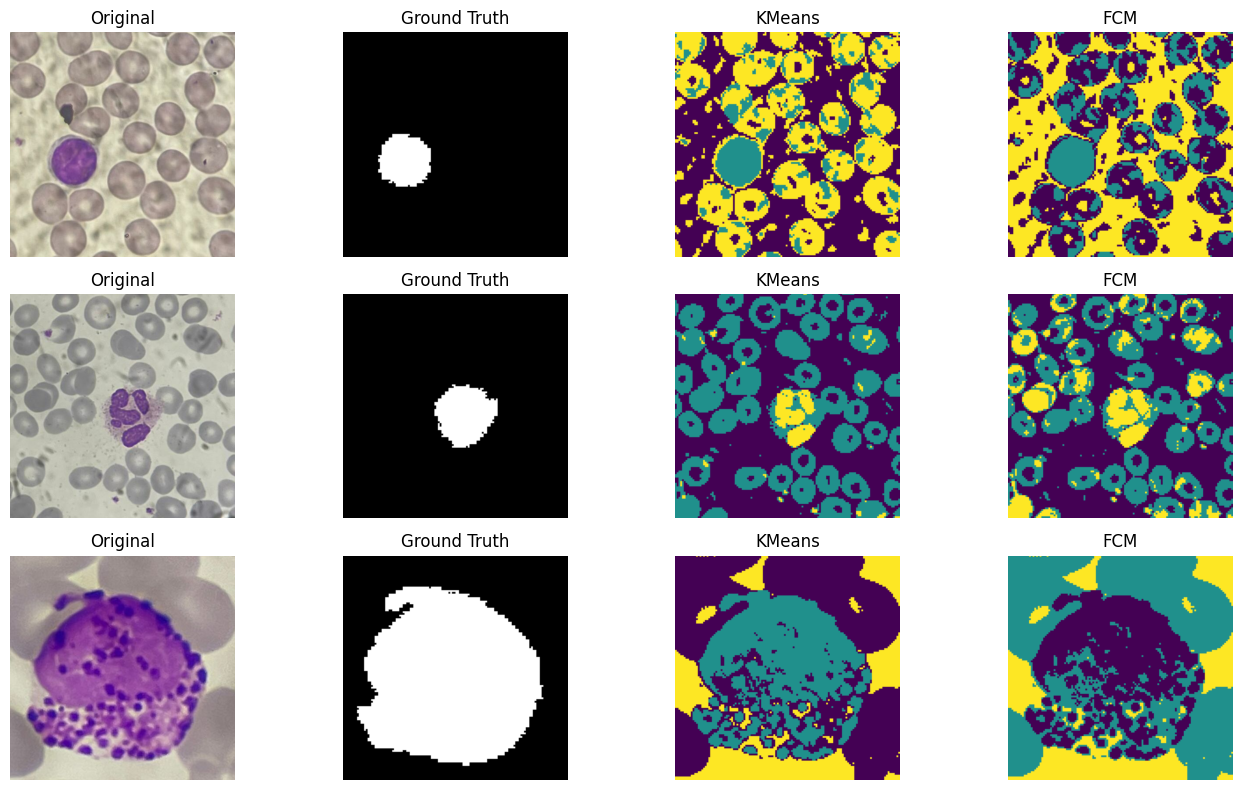

In [15]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

fig, ax = plt.subplots(3, 4, figsize=(14,8))

for i in range(3):

    image = images[i]
    mask  = masks[i]

    mask_r = cv2.resize(mask, (128,128))
    mask_bin = (mask_r > 0).astype(np.uint8)

    km_output  = apply_kmeans(image)
    fcm_output = apply_fcm(image)

    ax[i,0].imshow(image)
    ax[i,0].set_title("Original")
    ax[i,0].axis("off")

    ax[i,1].imshow(mask_bin, cmap="gray")
    ax[i,1].set_title("Ground Truth")
    ax[i,1].axis("off")

    ax[i,2].imshow(km_output, cmap="viridis")
    ax[i,2].set_title("KMeans")
    ax[i,2].axis("off")

    ax[i,3].imshow(fcm_output, cmap="viridis")
    ax[i,3].set_title("FCM")
    ax[i,3].axis("off")

plt.tight_layout()
plt.show()

In [11]:
km_results  = {'acc':[], 'prec':[], 'rec':[], 'f1':[]}
fcm_results = {'acc':[], 'prec':[], 'rec':[], 'f1':[]}

for img, msk in tqdm(zip(images, masks), total=len(images)):

    msk = cv2.resize(msk, (128,128))
    msk = (msk > 0).astype(np.uint8)

    #  KMeans 
    km_seg  = apply_kmeans(img)
    km_bin  = select_nucleus_cluster(km_seg, img)

    #  FCM 
    fcm_seg = apply_fcm(img)
    fcm_bin = select_nucleus_cluster(fcm_seg, img)

    # boundaries
    gt_edge  = get_edge(msk)
    km_edge  = get_edge(km_bin)
    fcm_edge = get_edge(fcm_bin)

    km_metrics  = boundary_scores(gt_edge, km_edge)
    fcm_metrics = boundary_scores(gt_edge, fcm_edge)

    for key, value in zip(km_results.keys(), km_metrics):
        km_results[key].append(value)

    for key, value in zip(fcm_results.keys(), fcm_metrics):
        fcm_results[key].append(value)

100%|██████████| 480/480 [03:21<00:00,  2.39it/s]


In [12]:
print(" KMeans Boundary Performance ")
for metric in km_results:
    print(f"{metric} : {np.mean(km_results[metric]):.4f}")

print("\n Fuzzy C-Means Boundary Performance ")
for metric in fcm_results:
    print(f"{metric} : {np.mean(fcm_results[metric]):.4f}")

 KMeans Boundary Performance 
acc : 0.6438
prec : 0.0347
rec : 0.5595
f1 : 0.0615

 Fuzzy C-Means Boundary Performance 
acc : 0.6367
prec : 0.0337
rec : 0.5646
f1 : 0.0602
